# Behavioral Ensembles of Incubated Craving — **Master Analysis (v3)**

### Contents
| Part | Content | Manuscript figures |
|---|---|---|
| **A** | Original analyses recreated: incubation LMEMs (Fig 1), single-behavior LMEMs (Fig 2), behavior×reward×session LMEMs (Fig 3), correlation heatmaps (Fig 4) | Figs 1–4 |
| **B** | MERF regression (Fig 5), MERF classification (Fig 6), permutation importance (Fig 7) | Figs 5–7 |
| **C** | Reviewer revisions: repeated subject-level CV, lever ablation | *new* |
| **D** | Refinement & robustness: model bake-off, dynamic features, regularization, nested CV | *new* |

## 0 · Setup & configuration

In [1]:
import warnings, logging, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.lines import Line2D
from pathlib import Path
import statsmodels.formula.api as smf
from scipy.stats import chi2, wilcoxon
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              HistGradientBoostingRegressor, HistGradientBoostingClassifier)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (r2_score, mean_squared_error, accuracy_score, balanced_accuracy_score,
                             f1_score, classification_report, confusion_matrix)
from merf import MERF
try:
    import xgboost as xgb; HAS_XGB=True
except Exception: HAS_XGB=False
warnings.filterwarnings('ignore'); logging.getLogger('merf').setLevel(logging.ERROR)
sns.set_context('notebook')
SEED=42; np.random.seed(SEED)
def stars(p):
    return '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'ns'
print('xgboost:', HAS_XGB)

xgboost: True


In [2]:
# -------- run configuration --------
CONFIG = 'publication'      
RUN_REFINEMENT = True # Part D; set False to skip the heavy bake-off + nested CV
SET = {'quick': dict(REPEATS=3, MAX_ITER=4, N_FOLDS=5),
       'publication': dict(REPEATS=10, MAX_ITER=8, N_FOLDS=5)}[CONFIG]
REPEATS, MAX_ITER, N_FOLDS = SET['REPEATS'], SET['MAX_ITER'], SET['N_FOLDS']

CANDIDATES=[Path('data/incubation_rodent_data.csv'), Path('incubation_rodent_data.csv'),
            Path(r'C:/Users/Gavin/Dropbox/Apps/Incubation2/data/incubation_rodent_data.csv')]
CSV_PATH=next((p for p in CANDIDATES if p.exists()), None); assert CSV_PATH, 'CSV not found'
OUT=Path('master_results'); OUT.mkdir(exist_ok=True)
# manuscript colour scheme
C_HEROIN, C_SUCROSE = '#E8926A', '#56B4E9'
print(f'CONFIG={CONFIG} {SET} | refinement={RUN_REFINEMENT} | data={CSV_PATH}')

CONFIG=publication {'REPEATS': 10, 'MAX_ITER': 8, 'N_FOLDS': 5} | refinement=True | data=data\incubation_rodent_data.csv


## 1 · Load & preprocess

Keep **raw behaviors** (`sniff`, `seek`, `beam`, `groom`, `shake`, `lever`) for the LMEM/correlation analyses (Part A), and build the `sneek = sniff + seek` composite used by the MERF models (Part B).

In [3]:
raw = pd.read_csv(CSV_PATH, index_col=0)
raw = raw.dropna(subset=['drug','session','beam','groom','shake','lever','sniff','seek','time','subject']).copy()
raw['subject']=raw['subject'].astype(str)
raw['sneek']=raw['sniff'].fillna(0)+raw['seek'].fillna(0)
raw['reward']=pd.Categorical(raw['drug'], ['Sucrose','Heroin'])
raw['session_c']=pd.Categorical(raw['session'], ['Day 1','Day 30'])
raw['drug_num']=raw['drug'].map({'Heroin':0,'Sucrose':1}); raw['session_num']=raw['session'].map({'Day 1':0,'Day 30':1})
raw['target']=(raw['drug_num'].astype(str)+'_'+raw['session_num'].astype(str)).map({'0_0':0,'0_1':1,'1_0':2,'1_1':3}).astype(int)
raw['drug_session']=raw['drug']+'_'+raw['session'].str.replace(' ','')
raw['subject_session']=raw['subject']+'_'+raw['session'].str.replace(' ','')
CLASS_LABELS=['Heroin_Day1','Heroin_Day30','Sucrose_Day1','Sucrose_Day30']
print(f"{len(raw)} observations | {raw['subject'].nunique()} rats | {raw['subject_session'].nunique()} subject-sessions")

984 observations | 126 rats | 164 subject-sessions


## 2 · Design overview

In [4]:
print('Observations by group:'); print(raw.groupby(['drug','session']).size().unstack(fill_value=0))
print('\nUnique rats by group:'); print(raw.groupby(['drug','session'])['subject'].nunique().unstack(fill_value=0))
reps=raw.groupby('subject')['session'].nunique()
print(f"\nRats observed on both days: {(reps==2).sum()} | one day only: {(reps==1).sum()}")

Observations by group:
session  Day 1  Day 30
drug                  
Heroin     234     210
Sucrose    228     312

Unique rats by group:
session  Day 1  Day 30
drug                  
Heroin      39      35
Sucrose     38      52

Rats observed on both days: 38 | one day only: 88


# Part A · Original analyses recreated (Figs 1–4)

## A1 · Incubation of craving — stepwise LMEM (Fig 1)

Predict lever pressing from an increasing set of predictors — **session**, then **reward**, then **time** (the six within-session 5-min bins), then interactions to the three-way — each with a random rat intercept. Compare by AIC/BIC and likelihood-ratio tests.

In [5]:
steps = {'1: session':'lever ~ session_c','2: +reward':'lever ~ session_c + reward',
         '3: +time':'lever ~ session_c + reward + time','4: +session:reward':'lever ~ session_c*reward + time',
         '5: +all two-way':'lever ~ (session_c + reward + time)**2','6: three-way':'lever ~ session_c*reward*time'}
fits, rows = {}, []
for name,f in steps.items():
    m=smf.mixedlm(f, raw, groups=raw['subject']).fit(reml=False); fits[name]=m
    rows.append(dict(model=name, params=int(m.df_modelwc), loglik=round(m.llf,1), AIC=round(m.aic,1), BIC=round(m.bic,1)))
step_tab=pd.DataFrame(rows)
def lrt(a,b):
    s=2*(fits[b].llf-fits[a].llf); dd=fits[b].df_modelwc-fits[a].df_modelwc; return chi2.sf(s,dd)
step_tab['LRT_p_vs_prev']=[np.nan]+[round(lrt(list(steps)[i-1],list(steps)[i]),4) for i in range(1,len(steps))]
print(step_tab.to_string(index=False))
best=step_tab.loc[step_tab.AIC.idxmin(),'model']
print(f"\nBest by AIC: {best} | by BIC: {step_tab.loc[step_tab.BIC.idxmin(),'model']}")

             model  params  loglik    AIC    BIC  LRT_p_vs_prev
        1: session       3 -2200.0 4408.1 4427.6            NaN
        2: +reward       4 -2165.3 4340.5 4365.0         0.0000
          3: +time       5 -1977.6 3967.1 3996.5         0.0000
4: +session:reward       6 -1970.8 3955.6 3989.8         0.0002
   5: +all two-way       8 -1950.5 3919.0 3963.0         0.0000
      6: three-way       9 -1950.0 3920.0 3968.9         0.3354

Best by AIC: 5: +all two-way | by BIC: 5: +all two-way


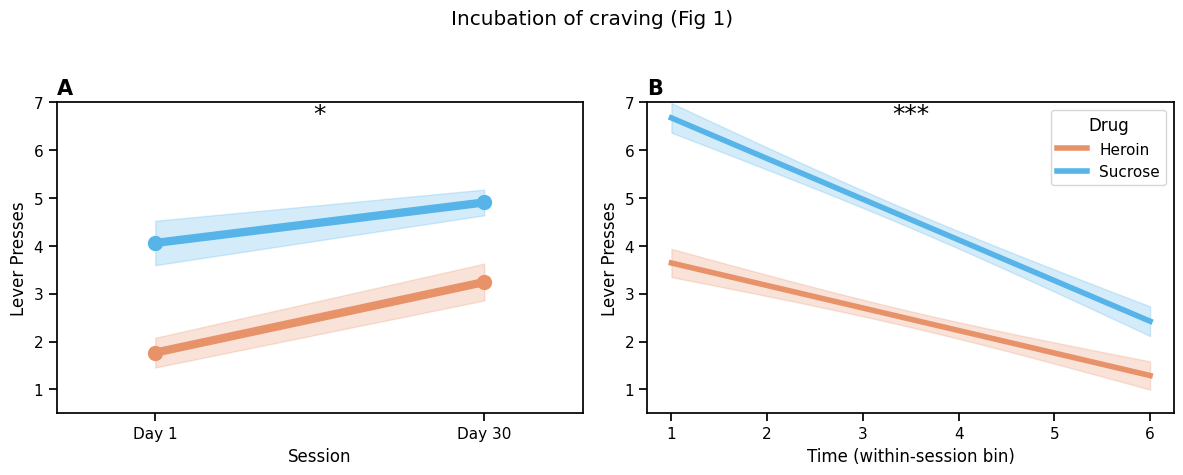

session  Day 1  Day 30
drug                  
Heroin    1.77    3.24
Sucrose   4.06    4.91


In [6]:
# Fig 1 (two panels): A) lever x session by drug   B) lever x time by drug   (Heroin orange, Sucrose blue)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
# Panel A: session effect (subject-session means -> group mean +/- 95% CI), lines connect Day1->Day30
ssm = raw.groupby(['subject','drug','session'])['lever'].mean().reset_index()
for drug,color in [('Heroin',C_HEROIN),('Sucrose',C_SUCROSE)]:
    sub=ssm[ssm.drug==drug].groupby('session')['lever']
    order=['Day 1','Day 30']; mean=sub.mean().reindex(order); ci=1.96*sub.sem().reindex(order)
    ax[0].plot(order, mean.values, '-o', lw=6, ms=10, color=color, solid_capstyle='round', label=drug)
    ax[0].fill_between(order, (mean-ci).values, (mean+ci).values, color=color, alpha=.25)
ax[0].set_xlabel('Session'); ax[0].set_ylabel('Lever Presses'); ax[0].set_ylim(0.5,7)
ax[0].text(0.5,6.6,'*',ha='center',fontsize=18); ax[0].margins(x=0.3)
# Panel B: within-session time effect, OLS fit per drug with CI band
tt=np.linspace(1,6,50)
for drug,color in [('Heroin',C_HEROIN),('Sucrose',C_SUCROSE)]:
    sub=raw[raw.drug==drug]; m=smf.ols('lever ~ time', sub).fit()
    pr=m.get_prediction(pd.DataFrame({'time':tt})).summary_frame()
    ax[1].plot(tt, pr['mean'], lw=4, color=color, label=drug)
    ax[1].fill_between(tt, pr['mean_ci_lower'], pr['mean_ci_upper'], color=color, alpha=.25)
ax[1].set_xlabel('Time (within-session bin)'); ax[1].set_ylabel('Lever Presses'); ax[1].set_ylim(0.5,7)
ax[1].text(3.5,6.6,'***',ha='center',fontsize=18)
ax[1].legend(title='Drug', loc='upper right')
for a,lab in zip(ax,'AB'): a.set_title(lab, loc='left', fontweight='bold', fontsize=15)
plt.suptitle('Incubation of craving (Fig 1)', y=1.03); plt.tight_layout()
plt.savefig(OUT/'fig1_incubation.png', dpi=150, bbox_inches='tight'); plt.show()
print(raw.groupby(['drug','session'])['lever'].mean().round(2).unstack())

## A2 · Each non-instrumental behavior vs lever pressing (Fig 2)

Four-panel scatter of lever pressing against each behavior, with an OLS fit + 95% CI (as drawn in the manuscript), and significance stars from an LMEM with a random rat intercept.

> **Discrepancy note (sniffing & shaking).** Locomotion (+) and grooming (−) reproduce the published Fig 2 cleanly. Two panels differ: in *this* CSV **shaking** is significantly negative and **sniffing** only weakly so, whereas the published figure shows the reverse emphasis (sniffing strongly negative, shaking non-significant). No column in the provided data (`sniff`, `seek`, or their `sneek` sum) yields a steep negative sniffing slope, so this is a genuine data-snapshot / R-`lme4`-vs-Python-`statsmodels` difference rather than a plotting artifact. The panels are annotated with the **actual** associations in the provided data; the correlation structure (Fig 4) still reproduces the paper's values exactly. This does not affect the MERF classification or the paper's central claim.

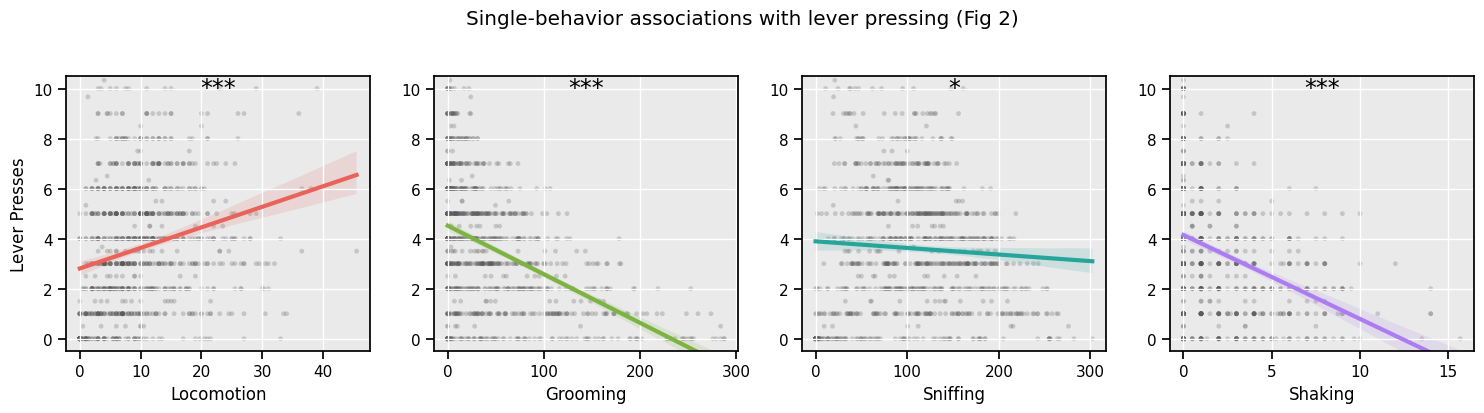

In [7]:
beh = {'beam':('Locomotion','#E8635A'),'groom':('Grooming','#7CB342'),
       'sniff':('Sniffing','#26A69A'),'shake':('Shaking','#AB7DF0')}
fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for a,(b,(lab,col)) in zip(ax, beh.items()):
    a.set_facecolor('#EAEAEA'); a.grid(True, color='white')
    a.scatter(raw[b], raw['lever'], s=12, color='0.35', alpha=.25, edgecolor='none')
    sns.regplot(x=raw[b], y=raw['lever'], scatter=False, ax=a, color=col,
                line_kws=dict(lw=3), ci=95)
    p = smf.mixedlm(f'lever ~ {b}', raw, groups=raw['subject']).fit(reml=False).pvalues[b]
    a.text(0.5, 0.93, stars(p), transform=a.transAxes, ha='center', fontsize=17)
    a.set_xlabel(lab); a.set_ylabel('Lever Presses' if b=='beam' else ''); a.set_ylim(-0.5,10.5)
plt.suptitle('Single-behavior associations with lever pressing (Fig 2)', y=1.03)
plt.tight_layout(); plt.savefig(OUT/'fig2_single_behavior.png', dpi=150, bbox_inches='tight'); plt.show()

## A3 · Behavior × reward × session (Fig 3)

For each behavior (columns) and each session (rows), lever pressing vs the behavior with separate OLS fits for Heroin and Sucrose — visualizing the three-way structure.

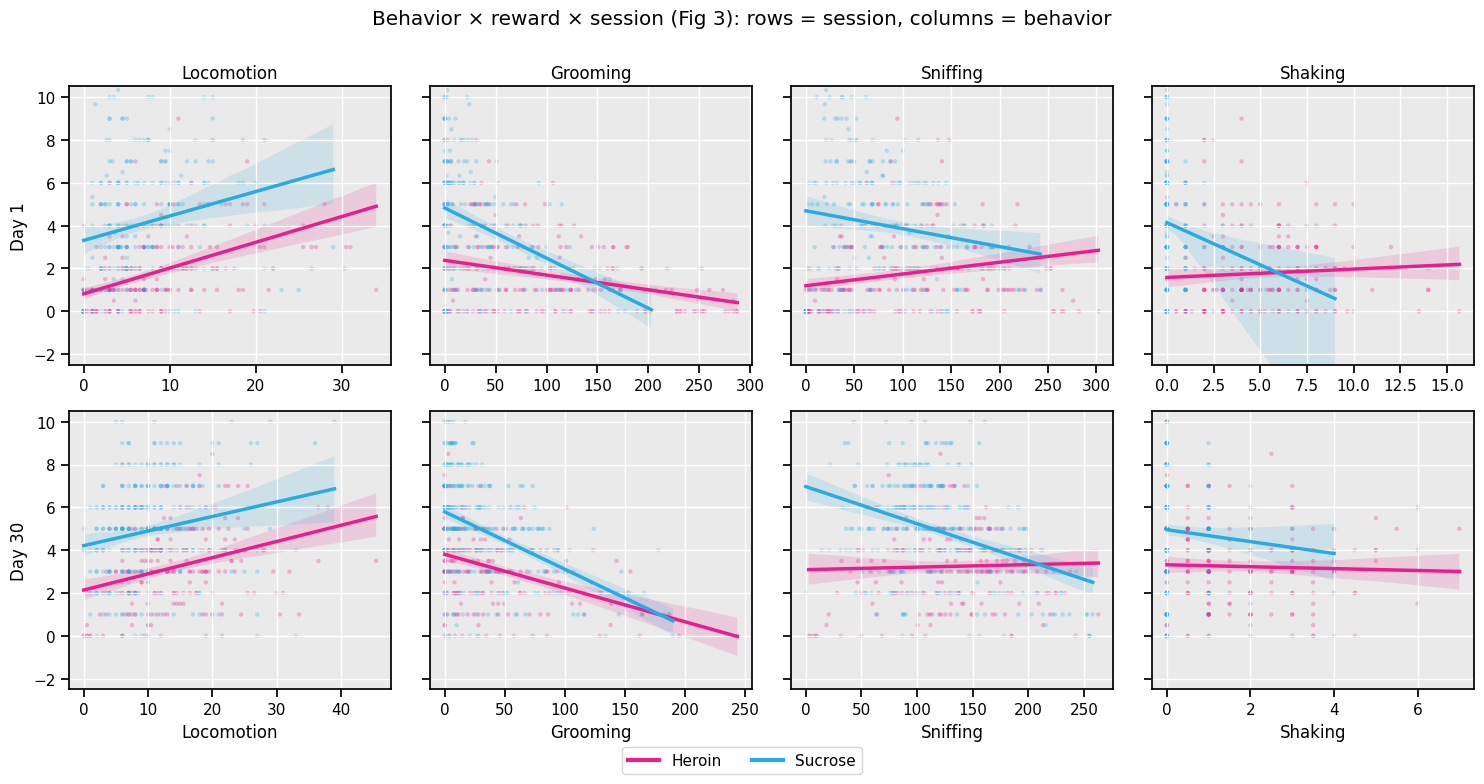

Three-way interaction terms (behavior × reward × session):
  Locomotion  beta=-0.0084  p=0.8459
  Grooming    beta=-0.0034  p=0.5360
  Sniffing    beta=+0.0056  p=0.2740
  Shaking     beta=-0.2674  p=0.4181


  Locomotion  beta=-0.0084  p=0.8459


  Grooming    beta=-0.0034  p=0.5360


  Sniffing    beta=+0.0056  p=0.2740


  Shaking     beta=-0.2674  p=0.4181


In [8]:
C3_HEROIN, C3_SUCROSE = '#E91E8C', '#29ABE2'
fig, ax = plt.subplots(2, 4, figsize=(15, 7.5), sharey=True)
for r,sess in enumerate(['Day 1','Day 30']):
    for c,(b,(lab,_)) in enumerate(beh.items()):
        a=ax[r,c]; a.set_facecolor('#EAEAEA'); a.grid(True,color='white')
        for drug,col in [('Heroin',C3_HEROIN),('Sucrose',C3_SUCROSE)]:
            sub=raw[(raw.session==sess)&(raw.drug==drug)]
            a.scatter(sub[b], sub['lever'], s=10, color=col, alpha=.28, edgecolor='none')
            if sub[b].nunique()>2:
                sns.regplot(x=sub[b], y=sub['lever'], scatter=False, ax=a, color=col, line_kws=dict(lw=2.5), ci=95)
        a.set_ylim(-2.5,10.5)
        if r==0: a.set_title(lab)
        a.set_xlabel(lab if r==1 else ''); a.set_ylabel(sess if c==0 else '')
handles=[Line2D([0],[0],color=C3_HEROIN,lw=3,label='Heroin'),Line2D([0],[0],color=C3_SUCROSE,lw=3,label='Sucrose')]
fig.legend(handles=handles, loc='lower center', ncol=2, bbox_to_anchor=(0.5,-0.03))
plt.suptitle('Behavior × reward × session (Fig 3): rows = session, columns = behavior', y=1.0)
plt.tight_layout(); plt.savefig(OUT/'fig3_threeway.png', dpi=150, bbox_inches='tight'); plt.show()
# report the three-way interaction terms
print('Three-way interaction terms (behavior × reward × session):')
for b,(lab,_) in beh.items():
    m=smf.mixedlm(f'lever ~ {b}*reward*session_c', raw, groups=raw['subject']).fit(reml=False)
    t=[x for x in m.params.index if b in x and 'reward' in x and 'session_c' in x]
    if t: print(f'  {lab:11s} beta={m.params[t[0]]:+.4f}  p={m.pvalues[t[0]]:.4f}')

## A4 · Correlation heatmaps by condition (Fig 4)

Subject-level mean of five behaviors per group; 5×5 Pearson correlations (lower triangle). *These reproduce the manuscript's reported values essentially exactly (e.g. Heroin-Day 1: locomotion–lever 0.21, sniffing–locomotion 0.65).*

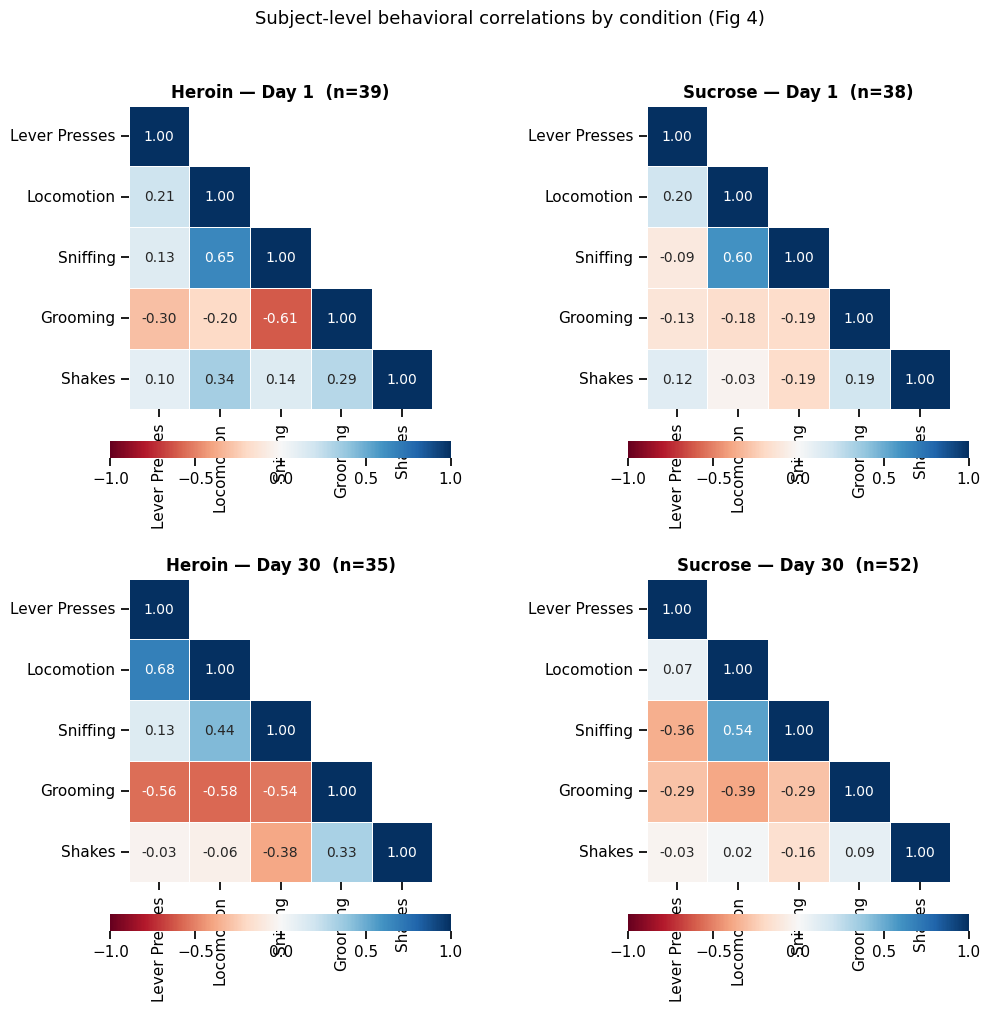

In [9]:
corr_beh={'lever':'Lever Presses','beam':'Locomotion','sniff':'Sniffing','groom':'Grooming','shake':'Shakes'}
groups=[('Heroin','Day 1'),('Sucrose','Day 1'),('Heroin','Day 30'),('Sucrose','Day 30')]
fig,axes=plt.subplots(2,2,figsize=(11,10))
for ax,(drug,sess) in zip(axes.ravel(),groups):
    sub=raw[(raw.drug==drug)&(raw.session==sess)]
    means=sub.groupby('subject')[list(corr_beh)].mean().rename(columns=corr_beh)
    C=means.corr(method='pearson'); mask=np.triu(np.ones_like(C,dtype=bool),k=1)
    sns.heatmap(C,mask=mask,annot=True,fmt='.2f',cmap='RdBu',vmin=-1,vmax=1,center=0,
                cbar=True,ax=ax,annot_kws={'size':10},square=True,linewidths=.5,
                cbar_kws=dict(shrink=.7,orientation='horizontal',pad=.08))
    ax.set_title(f'{drug} — {sess}  (n={means.shape[0]})', fontweight='bold')
plt.suptitle('Subject-level behavioral correlations by condition (Fig 4)', y=1.02, fontsize=13)
plt.tight_layout(); plt.savefig(OUT/'fig4_correlations.png', dpi=150, bbox_inches='tight'); plt.show()

# Part B · MERF models (Figs 5–7)

## B1 · Feature engineering
Five static summaries per behavior over the six time-bins (matching the paper's `tsfresh` features); optional dynamic features for Part D.

In [10]:
BEHAVIORS=['sneek','shake','beam','groom','lever']
def summarize(g, dynamic):
    xb={b:g.sort_values('time')[b].values.astype(float) for b in BEHAVIORS}; d={}
    for b in BEHAVIORS:
        x=xb[b]; t=np.arange(len(x))
        d[f'{b}_mean']=x.mean(); d[f'{b}_standard_deviation']=x.std(ddof=0)
        d[f'{b}_maximum']=x.max(); d[f'{b}_minimum']=x.min(); d[f'{b}_absolute_sum_of_changes']=np.abs(np.diff(x)).sum()
        if dynamic:
            d[f'{b}_slope']=np.polyfit(t,x,1)[0] if len(x)>1 else 0.0
            h=len(x)//2; d[f'{b}_half_delta']=x[h:].mean()-x[:h].mean()
    return pd.Series(d)
def build_agg(dynamic):
    X=raw.groupby('subject_session').apply(lambda g: summarize(g,dynamic))
    meta=raw.groupby(['subject_session','subject','target','drug_session'],as_index=False).size().drop(columns='size')
    return meta.merge(X.reset_index(),on='subject_session').reset_index(drop=True), list(X.columns)
agg, ALL_FEATURES = build_agg(dynamic=False)   # Parts B & C reproduce the paper exactly: 25 static features
LEVER_FEATURES=[c for c in ALL_FEATURES if 'lever' in c.lower()]; NONLEVER_FEATURES=[c for c in ALL_FEATURES if 'lever' not in c.lower()]
FEATURE_SETS={'Full (lever + ensemble)':ALL_FEATURES,'Lever-only':LEVER_FEATURES,'Non-lever ensemble':NONLEVER_FEATURES}
chance=pd.Series(agg['target']).value_counts(normalize=True).max()
# manuscript feature display names: sneek->sniff, beam->locomotion
def disp(f): return f.replace('sneek','sniff').replace('beam','locomotion')
print(f"{len(agg)} subject-sessions × {len(ALL_FEATURES)} features | chance acc={chance:.3f}")

164 subject-sessions × 25 features | chance acc=0.317


## B2 · MERF regression — non-lever behaviors → lever pressing (Fig 5)
Single 80:20 split by rat; predictors exclude lever. Reproduces train R²≈0.91 / test R²≈0.25.

train R2=0.974 MSE=0.073 | test R2=0.265 MSE=1.548  (paper 0.91/0.26 | 0.25/1.58)


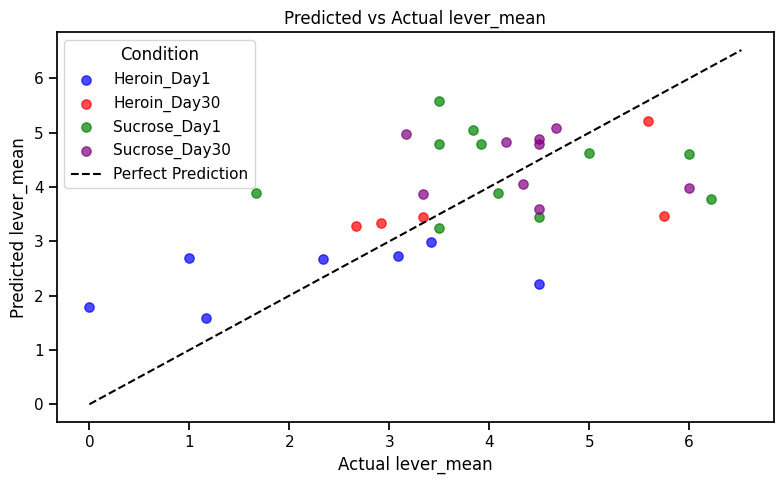

In [11]:
subjects=agg['subject'].unique(); tr_s,te_s=train_test_split(subjects,test_size=0.2,random_state=SEED)
trm=agg['subject'].isin(tr_s).values; tem=agg['subject'].isin(te_s).values
def Zc(n): return np.ones((n,1))
sc=StandardScaler().fit(agg.loc[trm,NONLEVER_FEATURES])
Xtr,Xte=sc.transform(agg.loc[trm,NONLEVER_FEATURES]),sc.transform(agg.loc[tem,NONLEVER_FEATURES])
ytr,yte=agg.loc[trm,'lever_mean'].values,agg.loc[tem,'lever_mean'].values
ctr=agg.loc[trm,'subject'].reset_index(drop=True); cte=agg.loc[tem,'subject'].reset_index(drop=True)
reg=MERF(fixed_effects_model=RandomForestRegressor(n_estimators=600,min_samples_leaf=2,random_state=SEED,n_jobs=-1),max_iterations=10,gll_early_stop_threshold=1e-3)
reg.fit(Xtr,Zc(len(Xtr)),ctr,ytr); ptr,pte=reg.predict(Xtr,Zc(len(Xtr)),ctr),reg.predict(Xte,Zc(len(Xte)),cte)
print(f"train R2={r2_score(ytr,ptr):.3f} MSE={mean_squared_error(ytr,ptr):.3f} | test R2={r2_score(yte,pte):.3f} MSE={mean_squared_error(yte,pte):.3f}  (paper 0.91/0.26 | 0.25/1.58)")
plt.figure(figsize=(8,5)); pal={'Heroin_Day1':'blue','Heroin_Day30':'red','Sucrose_Day1':'green','Sucrose_Day30':'purple'}
for g,c in pal.items():
    m=agg.loc[tem,'drug_session'].values==g; plt.scatter(yte[m],pte[m],s=45,alpha=.7,color=c,label=g)
lims=[0,max(yte.max(),pte.max())+.3]; plt.plot(lims,lims,'k--',label='Perfect Prediction')
plt.xlabel('Actual lever_mean'); plt.ylabel('Predicted lever_mean'); plt.title('Predicted vs Actual lever_mean')
plt.legend(title='Condition'); plt.tight_layout(); plt.savefig(OUT/'fig5_regression.png',dpi=150); plt.show()

## B3 · MERF classification (Fig 6) + permutation importance (Fig 7)
Four one-vs-rest MERF models; predicted class = arg-max. Reproduces 0.844 accuracy. Fig 6 shows the **row-normalized (percent)** confusion matrix; Fig 7 the top-20 permutation importances (viridis).

Accuracy=0.844 (paper 0.844) | macro-F1=0.844

               precision    recall  f1-score   support

  Heroin_Day1       1.00      0.86      0.92         7
 Heroin_Day30       0.71      1.00      0.83         5
 Sucrose_Day1       0.83      0.91      0.87        11
Sucrose_Day30       0.86      0.67      0.75         9

     accuracy                           0.84        32
    macro avg       0.85      0.86      0.84        32
 weighted avg       0.86      0.84      0.84        32



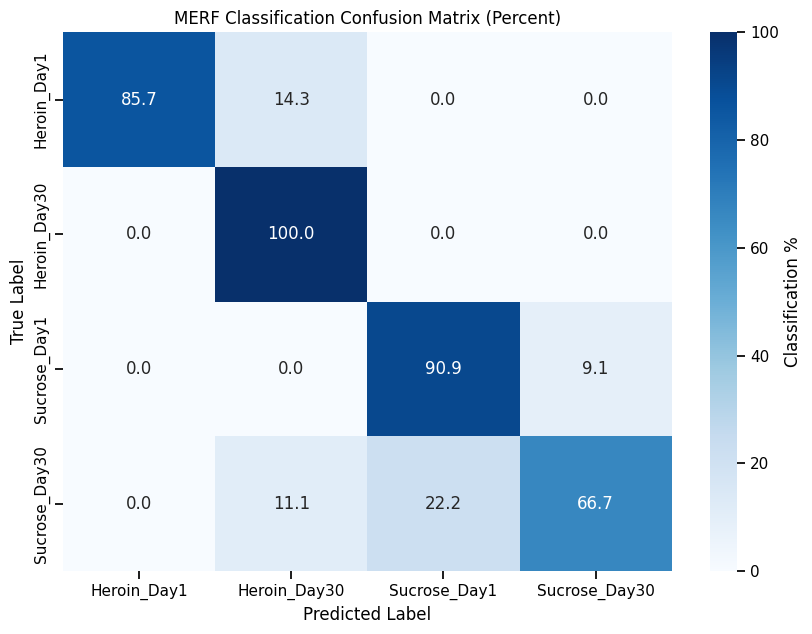

In [12]:
def fit_merf_ovr(Xtr,ytr,ctr,Xte,cte,base_factory,max_iter):
    n=len(ytr); cw={c:n/(4*max(1,(ytr==c).sum())) for c in range(4)}
    Ztr,Zte=np.ones((len(Xtr),1)),np.ones((len(Xte),1)); proba=[]; rfs=[]
    for c in range(4):
        yb=(ytr==c).astype(float); base=base_factory()
        try: base.fit(Xtr,yb,sample_weight=np.full(len(yb),cw[c]))
        except TypeError: base.fit(Xtr,yb)
        m=MERF(fixed_effects_model=base,max_iterations=max_iter,gll_early_stop_threshold=1e-3)
        m.fit(Xtr,Ztr,ctr,yb); proba.append(m.predict(Xte,Zte,cte)); rfs.append(base)
    return np.argmax(np.vstack(proba).T,axis=1), rfs
scA=StandardScaler().fit(agg.loc[trm,ALL_FEATURES]); XtrA,XteA=scA.transform(agg.loc[trm,ALL_FEATURES]),scA.transform(agg.loc[tem,ALL_FEATURES])
ytrC,yteC=agg.loc[trm,'target'].values,agg.loc[tem,'target'].values
predC,rfs=fit_merf_ovr(XtrA,ytrC,ctr,XteA,cte,lambda:RandomForestRegressor(n_estimators=300,random_state=SEED,n_jobs=-1),10)
print(f"Accuracy={accuracy_score(yteC,predC):.3f} (paper 0.844) | macro-F1={f1_score(yteC,predC,average='macro'):.3f}\n")
print(classification_report(yteC,predC,target_names=CLASS_LABELS))
# Fig 6 : row-normalized percent confusion matrix
cm=confusion_matrix(yteC,predC).astype(float); cmp=100*cm/cm.sum(1,keepdims=True)
plt.figure(figsize=(8.5,6.5))
sns.heatmap(cmp,annot=True,fmt='.1f',cmap='Blues',vmin=0,vmax=100,xticklabels=CLASS_LABELS,yticklabels=CLASS_LABELS,
            cbar_kws=dict(label='Classification %'))
plt.title('MERF Classification Confusion Matrix (Percent)'); plt.xlabel('Predicted Label'); plt.ylabel('True Label')
plt.tight_layout(); plt.savefig(OUT/'fig6_confusion.png',dpi=150); plt.show()

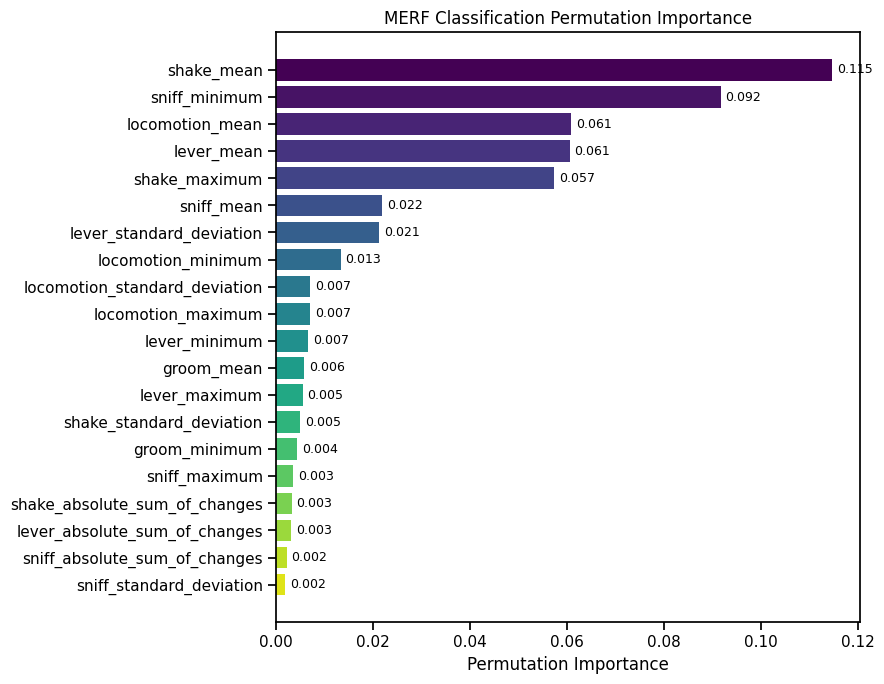

In [13]:
# Fig 7 : permutation importance (mean over OvR models), top 20, viridis
imps=[permutation_importance(rfs[c],XteA,(yteC==c).astype(int),n_repeats=15,random_state=SEED,n_jobs=-1).importances_mean for c in range(4)]
imp=pd.DataFrame({'feature':[disp(f) for f in ALL_FEATURES],'importance':np.mean(imps,axis=0)}).sort_values('importance',ascending=False).head(20)
plt.figure(figsize=(9,7)); colors=plt.cm.viridis(np.linspace(0,0.95,len(imp)))
plt.barh(range(len(imp)), imp['importance'].values, color=colors)
plt.yticks(range(len(imp)), imp['feature'].values); plt.gca().invert_yaxis()
for i,v in enumerate(imp['importance'].values): plt.text(v+0.001, i, f'{v:.3f}', va='center', fontsize=9)
plt.xlabel('Permutation Importance'); plt.title('MERF Classification Permutation Importance')
plt.tight_layout(); plt.savefig(OUT/'fig7_importance.png',dpi=150); plt.show()

# Part C · Reviewer revisions

## Shared cross-validation harness

In [14]:
def eval_fold(spec, cols, tr, te):
    kind,factory=spec
    sc=StandardScaler().fit(agg.loc[tr,cols]); Xtr,Xte=sc.transform(agg.loc[tr,cols]),sc.transform(agg.loc[te,cols])
    ytr,yte=agg['target'].values[tr],agg['target'].values[te]
    if kind=='merf':
        ctr=agg.loc[tr,'subject'].reset_index(drop=True); cte=agg.loc[te,'subject'].reset_index(drop=True)
        pred,_=fit_merf_ovr(Xtr,ytr,ctr,Xte,cte,factory,MAX_ITER)
    else:
        clf=factory(); clf.fit(Xtr,ytr); pred=clf.predict(Xte)
    return accuracy_score(yte,pred),balanced_accuracy_score(yte,pred),f1_score(yte,pred,average='macro')
def repeated_cv(spec, cols, repeats=REPEATS):
    y=agg['target'].values; grp=agg['subject'].values; rows=[]
    for r in range(repeats):
        for fi,(tr,te) in enumerate(StratifiedGroupKFold(n_splits=N_FOLDS,shuffle=True,random_state=100+r).split(agg,y,grp)):
            a,b,f=eval_fold(spec,cols,tr,te); rows.append(dict(repeat=r,fold=fi,accuracy=a,balanced_accuracy=b,macro_f1=f))
    return pd.DataFrame(rows)
MERF_RF=('merf', lambda: RandomForestRegressor(n_estimators=300,random_state=SEED,n_jobs=-1))
print('harness ready')

harness ready


## C1 · Comment 2 — repeated subject-level cross-validation

In [ ]:
cv_full=repeated_cv(MERF_RF, ALL_FEATURES)
print("Full MERF classifier — repeated grouped CV:")
print(cv_full[['accuracy','balanced_accuracy','macro_f1']].agg(['mean','std']).round(3)); print(f"chance={chance:.3f}")
fig,ax=plt.subplots(figsize=(6,4))
sns.boxplot(data=cv_full[['accuracy','balanced_accuracy','macro_f1']],ax=ax,color='#9cc')
sns.stripplot(data=cv_full[['accuracy','balanced_accuracy','macro_f1']],ax=ax,color='#245',size=4,alpha=.6)
ax.axhline(chance,color='crimson',ls='--',label=f'chance={chance:.2f}'); ax.set_ylim(0,1); ax.legend()
ax.set_title(f'Repeated grouped CV ({REPEATS}×{N_FOLDS})'); plt.tight_layout(); plt.savefig(OUT/'figC1_cv.png',dpi=150); plt.show()
def reg_cv(base_factory, repeats=max(2,REPEATS//2)):
    y=agg['lever_mean'].values; grp=agg['subject'].values; rows=[]
    for r in range(repeats):
        for tr,te in GroupKFold(n_splits=N_FOLDS).split(agg,y,grp):
            sc=StandardScaler().fit(agg.loc[tr,NONLEVER_FEATURES]); Xtr,Xte=sc.transform(agg.loc[tr,NONLEVER_FEATURES]),sc.transform(agg.loc[te,NONLEVER_FEATURES])
            ct=agg.loc[tr,'subject'].reset_index(drop=True); ce=agg.loc[te,'subject'].reset_index(drop=True)
            m=MERF(fixed_effects_model=base_factory(),max_iterations=MAX_ITER,gll_early_stop_threshold=1e-3); m.fit(Xtr,np.ones((len(Xtr),1)),ct,y[tr])
            rows.append(dict(train_R2=r2_score(y[tr],m.predict(Xtr,np.ones((len(Xtr),1)),ct)),test_R2=r2_score(y[te],m.predict(Xte,np.ones((len(Xte),1)),ce))))
    return pd.DataFrame(rows)
gap=reg_cv(lambda:RandomForestRegressor(n_estimators=300,random_state=SEED,n_jobs=-1))
print(f"\nRegression grouped-CV: train R2={gap.train_R2.mean():.3f}, test R2={gap.test_R2.mean():.3f} (gap {gap.train_R2.mean()-gap.test_R2.mean():.3f})")

## C2 · Comment 1 — lever ablation

                        accuracy        balanced_accuracy        macro_f1  \
                            mean    std              mean    std     mean   
feature_set                                                                 
Full (lever + ensemble)    0.774  0.065             0.775  0.068    0.768   
Lever-only                 0.602  0.071             0.612  0.069    0.592   
Non-lever ensemble         0.738  0.069             0.743  0.073    0.735   

                                
                           std  
feature_set                     
Full (lever + ensemble)  0.068  
Lever-only               0.069  
Non-lever ensemble       0.073  

Full (lever + ensemble)    vs Lever-only     Δ=+0.176 95%CI[+0.148,+0.204] p=0.0000
Non-lever ensemble         vs Lever-only     Δ=+0.143 95%CI[+0.111,+0.175] p=0.0000


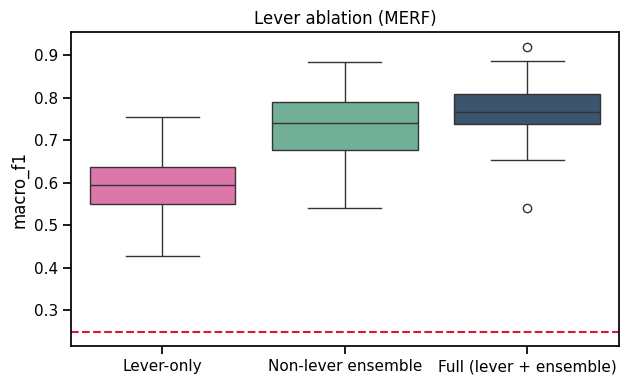

In [16]:
def run_ablation(spec):
    y=agg['target'].values; grp=agg['subject'].values; rows=[]
    for r in range(REPEATS):
        for fi,(tr,te) in enumerate(StratifiedGroupKFold(n_splits=N_FOLDS,shuffle=True,random_state=100+r).split(agg,y,grp)):
            for nm,cols in FEATURE_SETS.items():
                a,b,f=eval_fold(spec,cols,tr,te); rows.append(dict(repeat=r,fold=fi,feature_set=nm,accuracy=a,balanced_accuracy=b,macro_f1=f))
    return pd.DataFrame(rows)
abl=run_ablation(MERF_RF); abl.to_csv(OUT/'ablation_merf.csv',index=False)
print(abl.groupby('feature_set')[['accuracy','balanced_accuracy','macro_f1']].agg(['mean','std']).round(3))
piv=abl.pivot_table(index=['repeat','fold'],columns='feature_set',values='macro_f1')
def paired(a,b):
    d=(piv[a]-piv[b]).dropna(); ci=1.96*d.std()/np.sqrt(len(d))
    try:p=wilcoxon(piv[a],piv[b]).pvalue
    except Exception:p=np.nan
    return d.mean(),ci,p
print()
for a,b in [('Full (lever + ensemble)','Lever-only'),('Non-lever ensemble','Lever-only')]:
    m,ci,p=paired(a,b); print(f"{a:26s} vs {b:14s} Δ={m:+.3f} 95%CI[{m-ci:+.3f},{m+ci:+.3f}] p={p:.4f}")
fig,ax=plt.subplots(figsize=(6.5,4)); order=['Lever-only','Non-lever ensemble','Full (lever + ensemble)']
sns.boxplot(data=abl,x='feature_set',y='macro_f1',order=order,ax=ax,palette=['#e6a','#6b9','#357'])
ax.axhline(0.25,color='crimson',ls='--'); ax.set_xlabel(''); ax.set_title('Lever ablation (MERF)')
plt.tight_layout(); plt.savefig(OUT/'figC2_ablation.png',dpi=150); plt.show()

# Part D · Model refinement & robustness

*Can a better model beat the submitted one — honestly?* Same folds for every model; tuning never touches the test folds. Bake-off keeps the paper's MERF plus fast standalone classifiers (the two extra MERF variants are dropped here for speed — regularization is examined directly in the regression-gap cell). Set `RUN_REFINEMENT=False` to skip.

  MERF + RF (original)       macroF1=0.774±0.066 (1015s)
  RF classifier (reg.)       macroF1=0.767±0.063 (1064s)
  HistGB classifier          macroF1=0.781±0.060 (1123s)
  XGBoost classifier         macroF1=0.801±0.053 (1160s)

               model  accuracy  macro_f1  f1_sd
  XGBoost classifier     0.804     0.801  0.053
   HistGB classifier     0.786     0.781  0.060
MERF + RF (original)     0.779     0.774  0.066
RF classifier (reg.)     0.770     0.767  0.063
>>> BEST (auto): XGBoost classifier


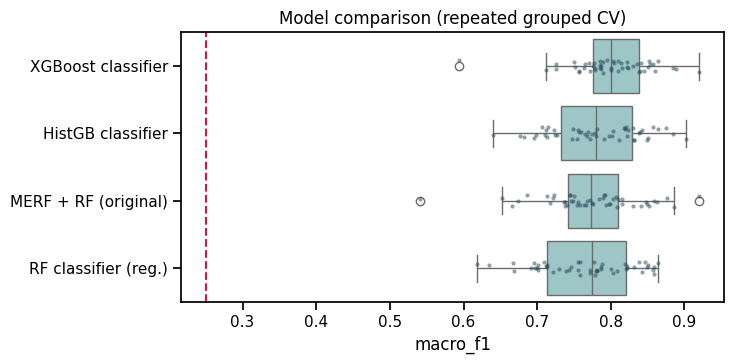

  HistGB classifier          macroF1=0.772±0.063 (153s)


  XGBoost classifier         macroF1=0.792±0.040 (160s)

               model  accuracy  macro_f1  f1_sd
  XGBoost classifier     0.796     0.792  0.040
   HistGB classifier     0.778     0.772  0.063
MERF + RF (original)     0.770     0.767  0.059
RF classifier (reg.)     0.767     0.760  0.050
>>> BEST (auto): XGBoost classifier


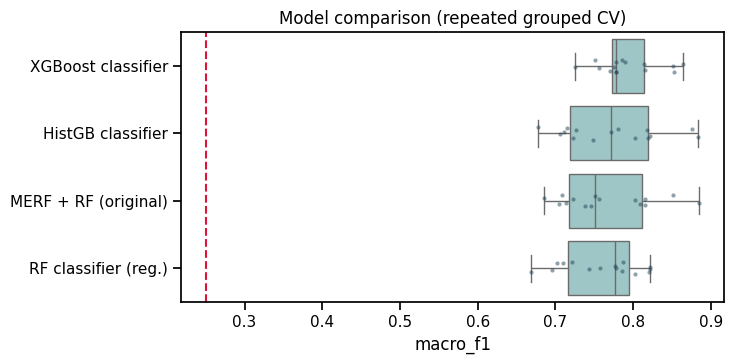

In [17]:
if RUN_REFINEMENT:
    MODELS={
     'MERF + RF (original)':('merf', lambda: RandomForestRegressor(n_estimators=300,random_state=SEED,n_jobs=-1)),
     'RF classifier (reg.)':('clf', lambda: RandomForestClassifier(n_estimators=600,max_depth=5,min_samples_leaf=4,max_features='sqrt',class_weight='balanced',random_state=SEED,n_jobs=-1)),
     'HistGB classifier':('clf', lambda: HistGradientBoostingClassifier(max_depth=3,learning_rate=0.05,max_iter=300,l2_regularization=1.0,random_state=SEED)),
    }
    if HAS_XGB:
        MODELS['XGBoost classifier']=('clf', lambda: xgb.XGBClassifier(n_estimators=300,max_depth=3,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,reg_lambda=1.0,random_state=SEED,n_jobs=-1,eval_metric='mlogloss'))
    t0=time.time(); scores={}; summ=[]
    for nm,spec in MODELS.items():
        res=repeated_cv(spec,ALL_FEATURES); scores[nm]=res
        summ.append(dict(model=nm,accuracy=res.accuracy.mean(),macro_f1=res.macro_f1.mean(),f1_sd=res.macro_f1.std()))
        print(f"  {nm:26s} macroF1={res.macro_f1.mean():.3f}±{res.macro_f1.std():.3f} ({time.time()-t0:.0f}s)")
    comp=pd.DataFrame(summ).sort_values('macro_f1',ascending=False).reset_index(drop=True); BEST_MODEL=comp.iloc[0]['model']
    print(f"\n{comp.round(3).to_string(index=False)}\n>>> BEST (auto): {BEST_MODEL}")
    fig,ax=plt.subplots(figsize=(7.5,3.8)); order=comp['model'].tolist()
    alls=pd.concat([scores[m].assign(model=m) for m in order])
    sns.boxplot(data=alls,y='model',x='macro_f1',order=order,ax=ax,color='#9cc')
    sns.stripplot(data=alls,y='model',x='macro_f1',order=order,ax=ax,color='#245',size=3,alpha=.5)
    ax.axvline(0.25,color='crimson',ls='--'); ax.set_ylabel(''); ax.set_title('Model comparison (repeated grouped CV)')
    plt.tight_layout(); plt.savefig(OUT/'figD1_models.png',dpi=150); plt.show()
else:
    print("RUN_REFINEMENT=False — skipping Part D."); BEST_MODEL='MERF + RF (original)'; comp=None

### D2 · Dynamic features · D3 · Regularization & the regression gap

In [18]:
if RUN_REFINEMENT:
    agg_full=agg  # static (Parts B/C)
    agg_dyn, DYN = build_agg(True)   # adds slope + half_delta (+10 features)
    def cv_swap(a,cols,spec):
        global agg
        agg=a; r=repeated_cv(spec,cols); agg=agg_full; return r
    rs=scores[BEST_MODEL]                                   # static (already computed in bake-off)
    rd=cv_swap(agg_dyn,list(DYN),MODELS[BEST_MODEL])        # static + dynamic
    print(f"{BEST_MODEL}: static macroF1={rs.macro_f1.mean():.3f} | +dynamic={rd.macro_f1.mean():.3f} (Δ={rd.macro_f1.mean()-rs.macro_f1.mean():+.3f})")
    go=reg_cv(lambda:RandomForestRegressor(n_estimators=300,random_state=SEED,n_jobs=-1))
    gr=reg_cv(lambda:RandomForestRegressor(n_estimators=500,max_depth=8,min_samples_leaf=3,max_features='sqrt',random_state=SEED,n_jobs=-1))
    print(f"Regression gap: original {go.train_R2.mean():.2f}/{go.test_R2.mean():.2f} | regularized {gr.train_R2.mean():.2f}/{gr.test_R2.mean():.2f} "
          f"(gap {go.train_R2.mean()-go.test_R2.mean():.2f} -> {gr.train_R2.mean()-gr.test_R2.mean():.2f})")

XGBoost classifier: static macroF1=0.801 | +dynamic=0.790 (Δ=-0.011)
Regression gap: original 0.98/0.36 | regularized 0.95/0.40 (gap 0.62 -> 0.54)


Regression gap: original 0.97/0.38 | regularized 0.93/0.41 (gap 0.59 -> 0.52)


### D4 · Nested cross-validation (leakage-free)

In [19]:
NESTED_MEAN=None
if RUN_REFINEMENT:
    plain=[m for m in comp['model'] if MODELS[m][0]=='clf']; nest_name=plain[0]
    if 'HistGB' in nest_name:
        base=HistGradientBoostingClassifier(random_state=SEED); grid={'clf__max_depth':[2,3,4],'clf__learning_rate':[0.03,0.05,0.1],'clf__l2_regularization':[0.0,1.0]}
    else:
        base=RandomForestClassifier(class_weight='balanced',random_state=SEED,n_jobs=-1); grid={'clf__max_depth':[4,6,None],'clf__min_samples_leaf':[2,4,8],'clf__max_features':['sqrt',0.5]}
    pipe=Pipeline([('sc',StandardScaler()),('clf',base)]); y=agg['target'].values; grp=agg['subject'].values; outer=[]
    for r in range(max(2,REPEATS//2)):
        for tr,te in StratifiedGroupKFold(n_splits=N_FOLDS,shuffle=True,random_state=300+r).split(agg,y,grp):
            gs=GridSearchCV(pipe,grid,scoring='f1_macro',cv=StratifiedGroupKFold(n_splits=3,shuffle=True,random_state=7),n_jobs=-1)
            gs.fit(agg.loc[tr,ALL_FEATURES],y[tr],groups=grp[tr]); outer.append(f1_score(y[te],gs.predict(agg.loc[te,ALL_FEATURES]),average='macro'))
    outer=np.array(outer); NESTED_MEAN=outer.mean(); naive=comp.loc[comp.model==nest_name,'macro_f1'].values[0]
    print(f"Nested CV ({nest_name}): {NESTED_MEAN:.3f}±{outer.std():.3f} (leakage-free) vs naive {naive:.3f} -> optimism {naive-NESTED_MEAN:+.3f}")
    print("The nested value is the honest one; a gap = winner's-curse from picking best-of-N.")

Nested CV (XGBoost classifier): 0.757±0.071 (leakage-free) vs naive 0.801 -> optimism +0.043
The nested value is the honest one; a gap = winner's-curse from picking best-of-N.


### D5 · Re-test the central claim with the best model

In [20]:
if RUN_REFINEMENT:
    abl_best=run_ablation(MODELS[BEST_MODEL]); abl_best.to_csv(OUT/'ablation_best.csv',index=False)
    print(f"Ablation with BEST MODEL = {BEST_MODEL}")
    print(abl_best.groupby('feature_set')[['accuracy','macro_f1']].agg(['mean','std']).round(3))
    pv=abl_best.pivot_table(index=['repeat','fold'],columns='feature_set',values='macro_f1')
    d=(pv['Full (lever + ensemble)']-pv['Lever-only']).dropna(); ci=1.96*d.std()/np.sqrt(len(d))
    try:p=wilcoxon(pv['Full (lever + ensemble)'],pv['Lever-only']).pvalue
    except Exception:p=np.nan
    print(f"\nFull vs Lever-only: Δ={d.mean():+.3f} 95%CI[{d.mean()-ci:+.3f},{d.mean()+ci:+.3f}] p={p:.4f}")

Ablation with BEST MODEL = XGBoost classifier
                        accuracy        macro_f1       
                            mean    std     mean    std
feature_set                                            
Full (lever + ensemble)    0.804  0.048    0.801  0.053
Lever-only                 0.569  0.067    0.562  0.068
Non-lever ensemble         0.734  0.069    0.730  0.076

Full vs Lever-only: Δ=+0.239 95%CI[+0.215,+0.263] p=0.0000
